# 🧪 Deep Learning Experiment Notebook
## Sign Language MNIST — Model Comparison

**Baseline reference:** Baseline CNN → Test Loss: 0.0472 | Test Acc: **99.36%** (~442K params)

| # | `MODEL_NAME` | Architecture | Key Idea |
|---|---|---|---|
| 1 | `baseline_cnn` | 3-block Conv (your original) | Reference |
| 2 | `densenet_cnn` | DenseNet-style dense connections | Feature reuse |
| 3 | `mobilenetv2_transfer` | MobileNetV2 pretrained (ImageNet) | Transfer learning |

In [1]:
# ── 0. Imports ────────────────────────────────────────────
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, Model
from tensorflow.keras.applications import MobileNetV2

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}\n")

TensorFlow  : 2.21.0
GPU available: False



In [ ]:
#   'baseline_cnn'        — your original 3-block CNN
#   'densenet_cnn'        — DenseNet dense connections
#   'mobilenetv2_transfer'— pretrained MobileNetV2 (needs 32x32+ & 3ch)

MODEL_NAME = "baseline_cnn"   # <── change me
TRAIN_CSV   = "Dataset/sign_mnist_train/sign_mnist_train.csv"
TEST_CSV    = "Dataset/sign_mnist_test/sign_mnist_test.csv"

OUTPUT_DIR  = f"outputs/{MODEL_NAME}"
LOG_DIR     = f"logs/{MODEL_NAME}"
IMG_SIZE    = 28
CHANNELS    = 1
NUM_CLASSES = 24
BATCH_SIZE  = 64
EPOCHS      = 20
LR          = 1e-3
SEED        = 42

# MobileNetV2 transfer needs RGB 32×32+++
TRANSFER    = (MODEL_NAME == "mobilenetv2_transfer")
if TRANSFER:
    IMG_SIZE  = 32
    CHANNELS  = 3

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"Model selected : {MODEL_NAME}")
print(f"Output dir     : {OUTPUT_DIR}")

Model selected : baseline_cnn
Output dir     : outputs/baseline_cnn


In [3]:
# ── 2. Load & Pre-process Data ────────────────────────────
def load_data(path, img_size=28, channels=1):
    df     = pd.read_csv(path)
    labels = df["label"].values.astype(np.int32)
    pixels = df.drop("label", axis=1).values.astype(np.float32) / 255.0
    images = pixels.reshape(-1, 28, 28, 1)          # always load as 28x28x1 first

    if img_size != 28 or channels != 1:
        # Resize and convert to RGB for transfer learning
        images = tf.image.resize(images, [img_size, img_size]).numpy()
        if channels == 3:
            images = np.repeat(images, 3, axis=-1)  # grayscale → pseudo-RGB
    return images, labels

print("Loading data …")
X_train, y_train = load_data(TRAIN_CSV, IMG_SIZE, CHANNELS)
X_test,  y_test  = load_data(TEST_CSV,  IMG_SIZE, CHANNELS)

LABEL_MAP   = {v: i for i, v in enumerate(sorted(set(y_train)))}
CLASS_NAMES = [chr(ord("A") + k) for k in sorted(LABEL_MAP.keys())
               if chr(ord("A") + k) not in ("J", "Z")]

y_train_idx = np.array([LABEL_MAP[l] for l in y_train])
y_test_idx  = np.array([LABEL_MAP[l] for l in y_test])

X_train, X_val, y_train_idx, y_val_idx = train_test_split(
    X_train,
    y_train_idx,
    test_size=0.1,
    random_state=42,
    stratify=y_train_idx
)

# print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Loading data …
Train: (24709, 28, 28, 1) | Val: (2746, 28, 28, 1) | Test: (7172, 28, 28, 1)
Classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [4]:
# ── 3. Data Augmentation Pipeline (same for all models) ───
augment_layer = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.10),
    # layers.RandomFlip("horizontal"),
], name="augmentation")

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
        ds = ds.map(lambda x, l: (augment_layer(x, training=True), l),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train_idx, training=True)
# val_ds   = make_dataset(X_test,  y_test_idx,  training=False)
# val_ds   = make_dataset(X_val, y_test_idx, training=False)
val_ds   = make_dataset(X_val, y_val_idx, training=False)

print("Datasets ready.")

Datasets ready.


In [ ]:
# ── 4. Model Definitions ───────────────────────────────────

# ─────────────────────────────────────────────────────────
# MODEL 1 — Baseline CNN (your original, kept for reference)
# ─────────────────────────────────────────────────────────

def build_baseline_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32,  (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32,  (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64,  (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,  (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="Baseline_CNN")

# ─────────────────────────────────────────────────────────
# MODEL 2 — DenseNet-style CNN
# ─────────────────────────────────────────────────────────
def dense_block(x, num_layers, growth_rate):
    """Each layer adds `growth_rate` new channels."""
    feature_list = [x]
    for _ in range(num_layers):
        z = layers.Concatenate()(feature_list) if len(feature_list) > 1 else feature_list[0]
        z = layers.BatchNormalization()(z); z = layers.Activation("relu")(z)
        z = layers.Conv2D(growth_rate, (3,3), padding="same")(z)
        feature_list.append(z)
    return layers.Concatenate()(feature_list)

def transition_block(x, compression=0.5):
    out_ch = max(1, int(x.shape[-1] * compression))
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(out_ch, (1,1), padding="same")(x)
    x = layers.AveragePooling2D()(x)
    return x

def build_densenet_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding="same")(inp)

    x = dense_block(x, num_layers=4, growth_rate=16)  # 28×28
    x = transition_block(x)                            # 14×14
    x = layers.Dropout(0.25)(x)

    x = dense_block(x, num_layers=4, growth_rate=16)  # 14×14
    x = transition_block(x)                            # 7×7
    x = layers.Dropout(0.25)(x)

    x = dense_block(x, num_layers=4, growth_rate=16)  # 7×7
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="DenseNet_CNN")

# ─────────────────────────────────────────────────────────
# MODEL 3 — MobileNetV2  (Transfer Learning)
# ─────────────────────────────────────────────────────────
def build_mobilenetv2_transfer(input_shape, num_classes):
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    # Phase 1: freeze all backbone layers
    base.trainable = False

    inp = layers.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    m   = Model(inp, out, name="MobileNetV2_Transfer")
    return m, base   # return base so we can unfreeze later

# ── Model Dispatcher ──────────────────────────────────────
input_shape = (IMG_SIZE, IMG_SIZE, CHANNELS)
mobilenet_base = None

dispatch = {
    "baseline_cnn":         build_baseline_cnn,
    "densenet_cnn":         build_densenet_cnn,
}

if MODEL_NAME == "mobilenetv2_transfer":
    model, mobilenet_base = build_mobilenetv2_transfer(input_shape, NUM_CLASSES)
elif MODEL_NAME in dispatch:
    model = dispatch[MODEL_NAME](input_shape, NUM_CLASSES)
else:
    raise ValueError(f"Unknown MODEL_NAME: '{MODEL_NAME}'. "
                     f"Choose from: {list(dispatch.keys()) + ['mobilenetv2_transfer']}")

model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,16

 Total params: 442,488 (1.69 MB)

 Trainable params: 441,336 (1.68 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [6]:
# ── 5. Compile ────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
# ── 6. Callbacks ──────────────────────────────────────────
cb_list = [
    callbacks.ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, "best_model.keras"),
        monitor="val_accuracy", save_best_only=True, verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1,
    ),
    callbacks.TensorBoard(log_dir=LOG_DIR, histogram_freq=1),
]
print("Callbacks ready.")

Callbacks ready.


In [ ]:
# ── 7. Train ──────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=cb_list,
)

# ── Fine-tune transfer model (Phase 2) ───────────────────
# Unfreeze the top 40 layers of MobileNetV2 and re-train
if MODEL_NAME == "mobilenetv2_transfer" and mobilenet_base is not None:
    print("\n─── Phase 2: Fine-tuning top MobileNetV2 layers ───")
    mobilenet_base.trainable = True
    
    # Freeze
    # for layer in mobilenet_base.layers[:-40]:
    # for layer in mobilenet_base.layers[:-60]:
    for layer in mobilenet_base.layers[:-80]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history_ft = model.fit(
        train_ds, epochs=20,
        validation_data=val_ds,
        callbacks=cb_list,
    )
    print("Fine-tuning complete.")

Epoch 1/20


386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3123 - loss: 2.5944
Epoch 1: val_accuracy improved from None to 0.43736, saving model to outputs/baseline_cnn/best_model.keras

Epoch 1: finished saving model to outputs/baseline_cnn/best_model.keras
387/387 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.4927 - loss: 1.7195 - val_accuracy: 0.4374 - val_loss: 1.7132 - learning_rate: 0.0010
Epoch 2/20
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7849 - loss: 0.6359
Epoch 2: val_accuracy improved from 0.43736 to 0.92571, saving model to outputs/baseline_cnn/best_model.keras

Epoch 2: finished saving model to outputs/baseline_cnn/best_model.keras
387/387 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.8234 - loss: 0.5273 - val_accuracy: 0.9257 - val_loss: 0.2325 - learning_rate: 0.0010
Epoch 3/20
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8906 - loss: 0.3240
Epoch 3: val_accuracy did not improve from 0.92571
387/387 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accur

In [9]:
# ── 8. Evaluate ───────────────────────────────────────────
print(f"\n── Evaluation [{MODEL_NAME}] ─────────────────────────")
loss, acc = model.evaluate(X_test, y_test_idx, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc * 100:.2f}%\n")

print(f"[Baseline reference] Loss: 0.0472 | Acc: 99.36%")
delta = (acc * 100) - 99.36
sign  = "+" if delta >= 0 else ""
print(f"Delta vs baseline     : {sign}{delta:.2f}%\n")

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test_idx, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
))


── Evaluation [baseline_cnn] ─────────────────────────
Test Loss     : 0.0021
Test Accuracy : 99.99%

[Baseline reference] Loss: 0.0472 | Acc: 99.36%
Delta vs baseline     : +0.63%

              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       331
           B     1.0000    1.0000    1.0000       432
           C     1.0000    1.0000    1.0000       310
           D     1.0000    1.0000    1.0000       245
           E     1.0000    0.9980    0.9990       498
           F     1.0000    1.0000    1.0000       247
           G     1.0000    1.0000    1.0000       348
           H     1.0000    1.0000    1.0000       436
           I     1.0000    1.0000    1.0000       288
           K     1.0000    1.0000    1.0000       331
           L     1.0000    1.0000    1.0000       209
           M     0.9975    1.0000    0.9987       394
           N     1.0000    1.0000    1.0000       291
           O     1.0000    1.0000    1.0000       246
      

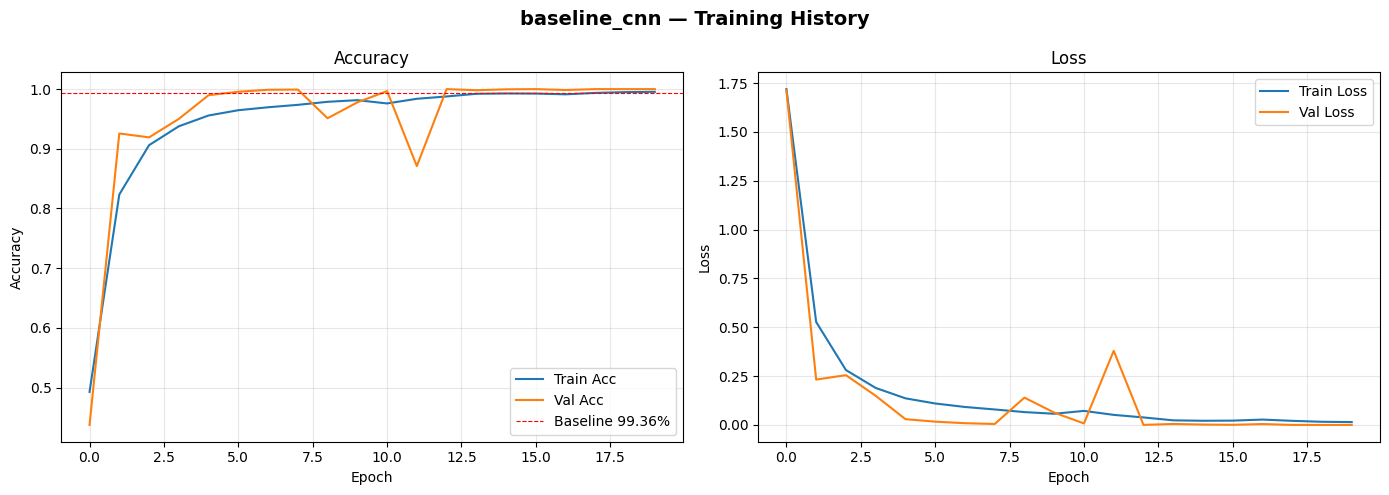

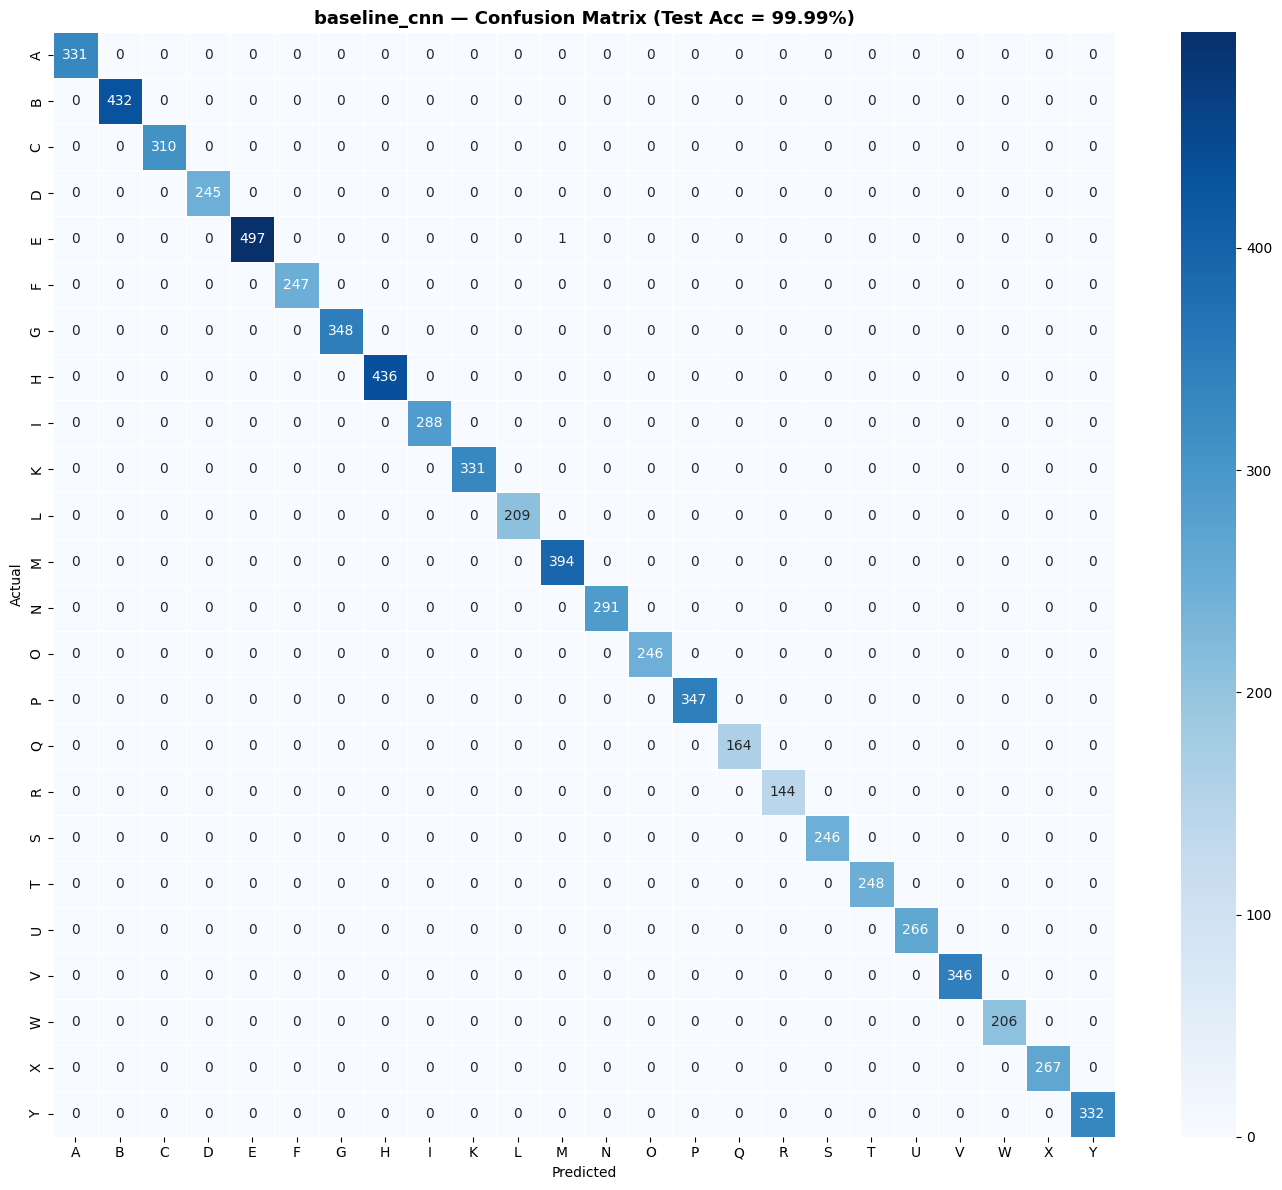


✅  Done! Outputs saved to ./outputs/baseline_cnn/
📊  TensorBoard:  tensorboard --logdir=logs/baseline_cnn


In [10]:
# ── 9. Plots ──────────────────────────────────────────────
# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{MODEL_NAME} — Training History", fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"],     label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].axhline(0.9936, color="red", linestyle="--", linewidth=0.8, label="Baseline 99.36%")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"), dpi=150)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test_idx, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=ax)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix (Test Acc = {acc*100:.2f}%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

print(f"\n✅  Done! Outputs saved to ./{OUTPUT_DIR}/")
print(f"📊  TensorBoard:  tensorboard --logdir=logs/{MODEL_NAME}")

In [12]:
def build_baseline_cnn(
    input_shape,
    num_classes,
    filters=(32, 64, 128),
    dropout_rate=0.25,
    fc_dropout=0.50,
    lr=1e-3,
    mixed_kernel=False
):
    inp = layers.Input(shape=input_shape)

    k1 = (5, 5) if mixed_kernel else (3, 3)
    k2 = (3, 3)

    x = layers.Conv2D(filters[0], k1, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters[0], k2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(filters[1], k1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters[1], k2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(filters[2], k1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(fc_dropout)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out, name="Baseline_CNN")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [13]:
from itertools import product
import pandas as pd
import numpy as np
import gc

param_grid = {
    # "lr": [1e-3, 5e-4, 1e-4],
    "lr": [5e-4],
    "dropout_rate": [0.25, 0.30,0.40],
    # "mixed_kernel": [False, True],
    "filters": [
        # (32, 64, 128),
        (32, 64, 256),
        (64, 128, 256)
    ]
}

all_configs = list(product(
    param_grid["lr"],
    param_grid["dropout_rate"],
    # param_grid["mixed_kernel"],
    param_grid["filters"]
))

print("Total configs:", len(all_configs))

Total configs: 6


In [14]:
results = []

# for i, (lr, dropout_rate, mixed_kernel, filters) in enumerate(all_configs, 1):
# for i, (lr, filters) in enumerate(all_configs, 1):
for i, (lr, dropout_rate, filters) in enumerate(all_configs, 1):

    # print(f"\n=== [{i}/{len(all_configs)}] lr={lr}, drop={dropout_rate}, mixed={mixed_kernel}, filters={filters}")
    print(f"\n=== [{i}/{len(all_configs)}] lr={lr}, drop={dropout_rate}, filters={filters}")

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_baseline_cnn(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        num_classes=NUM_CLASSES,
        filters=filters,
        dropout_rate=dropout_rate,
        fc_dropout=0.50,
        lr=lr,
        # mixed_kernel=mixed_kernel
    )

    cb_search = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True
        )
    ]

    # exp_name = f"lr{lr}_drop{dropout_rate}_mk{mixed_kernel}_f{filters}".replace(" ", "")
    exp_name = f"lr{lr}_f{filters}".replace(" ", "")
    save_path = f"outputs/gridsearch/{exp_name}.keras"

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        verbose=0,
        callbacks=cb_search
    )

    results.append({
        "lr": lr,
        "dropout_rate": dropout_rate,
        # "mixed_kernel": mixed_kernel,
        "filters": str(filters),
        "best_val_acc": max(history.history["val_accuracy"]),
        "best_val_loss": min(history.history["val_loss"]),
        "epochs_ran": len(history.history["loss"])
    })


=== [1/6] lr=0.0005, drop=0.25, filters=(32, 64, 256)

=== [2/6] lr=0.0005, drop=0.25, filters=(64, 128, 256)

=== [3/6] lr=0.0005, drop=0.3, filters=(32, 64, 256)

=== [4/6] lr=0.0005, drop=0.3, filters=(64, 128, 256)

=== [5/6] lr=0.0005, drop=0.4, filters=(32, 64, 256)

=== [6/6] lr=0.0005, drop=0.4, filters=(64, 128, 256)


In [15]:
df_results = pd.DataFrame(results).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

df_results["best_val_acc"] = (df_results["best_val_acc"] * 100).round(2)
df_results["best_val_loss"] = df_results["best_val_loss"].round(4)

display(df_results)
df_results.to_csv("gridsearch_baseline_results.csv", index=False)

print("\nAverage performance by learning rate")
display(df_results.groupby("lr")[["best_val_acc", "best_val_loss"]].mean())

print("\nAverage performance by dropout")
display(df_results.groupby("dropout_rate")[["best_val_acc", "best_val_loss"]].mean())

# print("\nAverage performance by mixed_kernel")
# display(df_results.groupby("mixed_kernel")[["best_val_acc", "best_val_loss"]].mean())

print("\nAverage performance by filters")
display(df_results.groupby("filters")[["best_val_acc", "best_val_loss"]].mean())

,lr,dropout_rate,filters,best_val_acc,best_val_loss,epochs_ran
0,0.0005,0.30,"(64, 128, 256)",99.96,0.0057,8
1,0.0005,0.25,"(64, 128, 256)",99.93,0.0081,7
2,0.0005,0.40,"(32, 64, 256)",99.93,0.0065,13
3,0.0005,0.25,"(32, 64, 256)",99.85,0.0056,9
4,0.0005,0.30,"(32, 64, 256)",99.71,0.0102,12
5,0.0005,0.40,"(64, 128, 256)",99.49,0.0523,7



Average performance by learning rate


,best_val_acc,best_val_loss
lr,,
0.0005,99.811667,0.014733



Average performance by dropout


,best_val_acc,best_val_loss
dropout_rate,,
0.25,99.890,0.00685
0.30,99.835,0.00795
0.40,99.710,0.02940



Average performance by filters


,best_val_acc,best_val_loss
filters,,
"(32, 64, 256)",99.830000,0.007433
"(64, 128, 256)",99.793333,0.022033


In [16]:
def build_densenet_basic(
    input_shape,
    num_classes,
    growth_rate=16,
    dropout_rate=0.2,
    lr=1e-3
):
    def conv_block(x, growth_rate, dropout_rate):
        y = layers.BatchNormalization()(x)
        y = layers.Activation("relu")(y)
        y = layers.Conv2D(growth_rate, (3, 3), padding="same", use_bias=False)(y)
        if dropout_rate > 0:
            y = layers.Dropout(dropout_rate)(y)
        x = layers.Concatenate()([x, y])
        return x

    def dense_block(x, num_layers, growth_rate, dropout_rate):
        for _ in range(num_layers):
            x = conv_block(x, growth_rate, dropout_rate)
        return x

    def transition_layer(x):
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(int(x.shape[-1] * 0.5), (1, 1), padding="same", use_bias=False)(x)
        x = layers.AveragePooling2D((2, 2))(x)
        return x

    inputs = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)

    # Dense Block 1
    x = dense_block(x, num_layers=2, growth_rate=growth_rate, dropout_rate=dropout_rate)
    x = transition_layer(x)

    # Dense Block 2
    x = dense_block(x, num_layers=2, growth_rate=growth_rate, dropout_rate=dropout_rate)
    x = transition_layer(x)

    # Dense Block 3
    x = dense_block(x, num_layers=2, growth_rate=growth_rate, dropout_rate=dropout_rate)

    # Head
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="DenseNet_Basic")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [17]:
param_grid_densenet = {
    "lr": [1e-3, 5e-4],
    "growth_rate": [12],
    "dropout_rate": [0.30, 0.40]
}

In [18]:
all_configs_densenet = list(product(
    param_grid_densenet["lr"],
    param_grid_densenet["growth_rate"],
    param_grid_densenet["dropout_rate"]
))

print("Total DenseNet configs:", len(all_configs_densenet))

results_densenet = []

for i, (lr, growth_rate, dropout_rate) in enumerate(all_configs_densenet, 1):
    print(f"\n=== DenseNet [{i}/{len(all_configs_densenet)}] lr={lr}, growth_rate={growth_rate}, dropout={dropout_rate}")

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_densenet_basic(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        num_classes=NUM_CLASSES,
        growth_rate=growth_rate,
        dropout_rate=dropout_rate,
        lr=lr
    )

    cb_search = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        verbose=0,
        callbacks=cb_search
    )

    best_val_acc = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    print(f"Done [{i}/{len(all_configs_densenet)}] | best_val_acc={best_val_acc:.4f}")

    results_densenet.append({
        "lr": lr,
        "growth_rate": growth_rate,
        "dropout_rate": dropout_rate,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "epochs_ran": len(history.history["loss"])
    })

Total DenseNet configs: 4

=== DenseNet [1/4] lr=0.001, growth_rate=12, dropout=0.3
Done [1/4] | best_val_acc=0.9093

=== DenseNet [2/4] lr=0.001, growth_rate=12, dropout=0.4
Done [2/4] | best_val_acc=0.5138

=== DenseNet [3/4] lr=0.0005, growth_rate=12, dropout=0.3
Done [3/4] | best_val_acc=0.8423

=== DenseNet [4/4] lr=0.0005, growth_rate=12, dropout=0.4
Done [4/4] | best_val_acc=0.4035


In [19]:
df_densenet = pd.DataFrame(results_densenet).sort_values(
    "best_val_acc", ascending=False
).reset_index(drop=True)

df_densenet["best_val_acc"] = (df_densenet["best_val_acc"] * 100).round(2)
df_densenet["best_val_loss"] = df_densenet["best_val_loss"].round(4)

display(df_densenet)
df_densenet.to_csv("gridsearch_densenet_basic_results.csv", index=False)

,lr,growth_rate,dropout_rate,best_val_acc,best_val_loss,epochs_ran
0,0.0010,12,0.3,90.93,0.2464,12
1,0.0005,12,0.3,84.23,0.4210,14
2,0.0010,12,0.4,51.38,1.5462,8
3,0.0005,12,0.4,40.35,1.9205,7



🏆 Training Best DenseNet Config:
   lr=0.001, growth_rate=12.0, dropout=0.3
Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 45s 110ms/step - accuracy: 0.2099 - loss: 2.4871 - val_accuracy: 0.1176 - val_loss: 3.3436
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.4495 - loss: 1.5587 - val_accuracy: 0.3802 - val_loss: 1.5585
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 38s 99ms/step - accuracy: 0.6242 - loss: 1.0629 - val_accuracy: 0.3103 - val_loss: 2.6908
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - accuracy: 0.7139 - loss: 0.8092 - val_accuracy: 0.6821 - val_loss: 0.8618
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 36s 94ms/step - accuracy: 0.7632 - loss: 0.6763 - val_accuracy: 0.1996 - val_loss: 5.4206
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.7971 - loss: 0.5843 - val_accuracy: 0.7615 - val_loss: 0.6413
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 36s 94ms/step - accuracy: 0.8248 - loss: 0.5122 - val_accuracy: 0.8616 - val_loss: 0.3939
Epoch 8/20

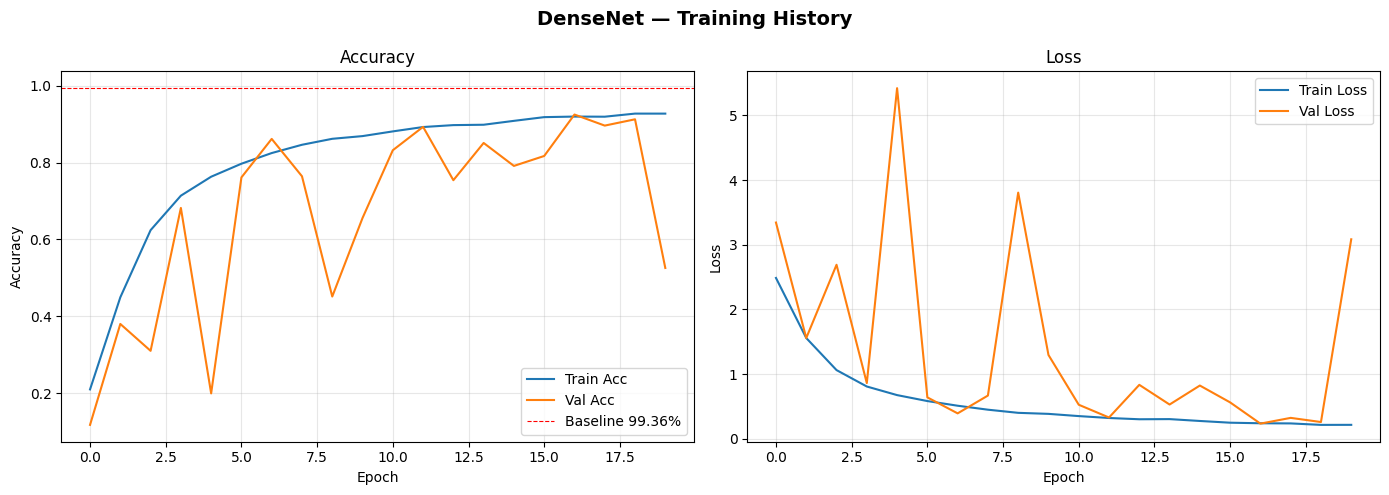

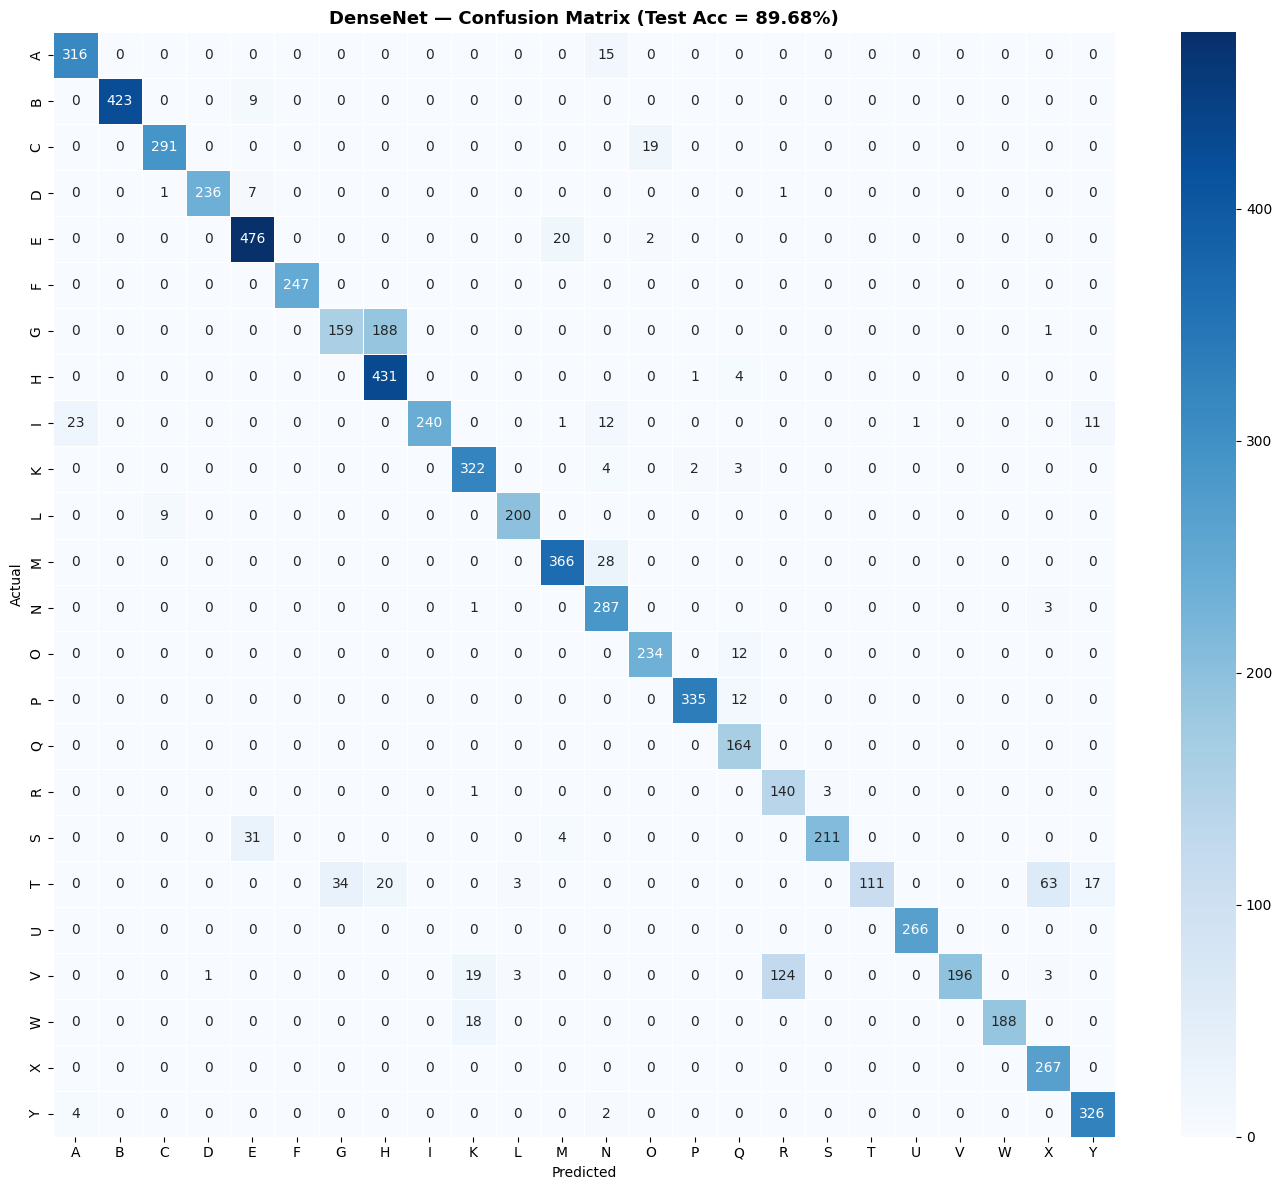


✅  DenseNet plots saved!


In [20]:
# ── Train Best DenseNet Model & Plot ──────────────────
best_densenet_row = df_densenet.iloc[0]
print(f"\n🏆 Training Best DenseNet Config:")
print(f"   lr={best_densenet_row['lr']}, growth_rate={best_densenet_row['growth_rate']}, "
      f"dropout={best_densenet_row['dropout_rate']}")

tf.keras.backend.clear_session()
gc.collect()

best_densenet_model = build_densenet_basic(
    input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
    num_classes=NUM_CLASSES,
    growth_rate=int(best_densenet_row['growth_rate']),
    dropout_rate=best_densenet_row['dropout_rate'],
    lr=best_densenet_row['lr']
)

cb_final = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

densenet_history = best_densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1,
    callbacks=cb_final
)

# Evaluate best DenseNet
print(f"\n── DenseNet Evaluation ─────────────────────────")
# Reset IMG_SIZE back to 28 for evaluation
IMG_SIZE_ORIG = 28
X_test_resize = tf.image.resize(X_test, [IMG_SIZE_ORIG, IMG_SIZE_ORIG]).numpy()
loss_dn, acc_dn = best_densenet_model.evaluate(X_test, y_test_idx, verbose=0)
print(f"Test Loss     : {loss_dn:.4f}")
print(f"Test Accuracy : {acc_dn * 100:.2f}%")
print(f"Delta vs baseline: {(acc_dn * 100) - 99.36:+.2f}%")

y_pred_dn = np.argmax(best_densenet_model.predict(X_test, verbose=0), axis=1)
cm_dn = confusion_matrix(y_test_idx, y_pred_dn)

# Plot DenseNet Training History & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"DenseNet — Training History", fontsize=14, fontweight="bold")

axes[0].plot(densenet_history.history["accuracy"],     label="Train Acc")
axes[0].plot(densenet_history.history["val_accuracy"], label="Val Acc")
axes[0].axhline(0.9936, color="red", linestyle="--", linewidth=0.8, label="Baseline 99.36%")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(densenet_history.history["loss"],     label="Train Loss")
axes[1].plot(densenet_history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/densenet_training_history.png", dpi=150)
plt.show()

# DenseNet Confusion Matrix
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_dn, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=ax)
ax.set_title(f"DenseNet — Confusion Matrix (Test Acc = {acc_dn*100:.2f}%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/densenet_confusion_matrix.png", dpi=150)
plt.show()

print(f"\n✅  DenseNet plots saved!")

mobilenet

In [21]:
def build_mobilenet_basic(
    input_shape,
    num_classes,
    dropout_rate=0.3,
    dense_units=128,
    lr=1e-3,
    unfreeze_last_n=0
):
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    base.trainable = True
    for layer in base.layers[:-unfreeze_last_n] if unfreeze_last_n > 0 else base.layers:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_Basic")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
param_grid_mobile = {
    "lr": [1e-3, 1e-4],
    "dropout_rate": [0.2, 0.3],
    "unfreeze_last_n": [0, 20]
}

all_configs_mobile = list(product(
    param_grid_mobile["lr"],
    param_grid_mobile["dropout_rate"],
    param_grid_mobile["unfreeze_last_n"]
))

print("Total MobileNet configs:", len(all_configs_mobile))

Total MobileNet configs: 8


In [26]:
IMG_SIZE = 96
CHANNELS = 3

# ── Reload data with new dimensions for MobileNet ──────
print("Reloading data for MobileNet (96x96x3)...")
X_train_mb, y_train_mb = load_data(TRAIN_CSV, IMG_SIZE, CHANNELS)
X_test_mb,  y_test_mb  = load_data(TEST_CSV,  IMG_SIZE, CHANNELS)

# Apply the same label mapping as original data
y_train_idx_mb = np.array([LABEL_MAP[l] for l in y_train_mb])
y_test_idx_mb = np.array([LABEL_MAP[l] for l in y_test_mb])

X_train_mb, X_val_mb, y_train_idx_mb, y_val_idx_mb = train_test_split(
    X_train_mb,
    y_train_idx_mb,
    test_size=0.1,
    random_state=42,
    stratify=y_train_idx_mb
)

# Recreate datasets for MobileNet
train_ds_mb = make_dataset(X_train_mb, y_train_idx_mb, training=True)
val_ds_mb   = make_dataset(X_val_mb, y_val_idx_mb, training=False)
print(f"MobileNet data ready: Train {X_train_mb.shape} | Val {X_val_mb.shape} | Test {X_test_mb.shape}\n")

results_mobile = []

for i, (lr, dropout_rate, unfreeze_last_n) in enumerate(all_configs_mobile, 1):
    print(f"\n=== MobileNet [{i}/{len(all_configs_mobile)}] "
          f"lr={lr}, dropout={dropout_rate}, unfreeze_last_n={unfreeze_last_n}")

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenet_basic(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        num_classes=NUM_CLASSES,
        dropout_rate=dropout_rate,
        dense_units=128,
        lr=lr,
        unfreeze_last_n=unfreeze_last_n
    )

    cb_search = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        train_ds_mb,
        validation_data=val_ds_mb,
        epochs=10,
        verbose=0,
        callbacks=cb_search
    )

    best_val_acc = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    print(f"Done [{i}/{len(all_configs_mobile)}] | best_val_acc={best_val_acc:.4f}")

    results_mobile.append({
        "lr": lr,
        "dropout_rate": dropout_rate,
        "unfreeze_last_n": unfreeze_last_n,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "epochs_ran": len(history.history["loss"])
    })

Reloading data for MobileNet (96x96x3)...
MobileNet data ready: Train (24709, 96, 96, 3) | Val (2746, 96, 96, 3) | Test (7172, 96, 96, 3)


=== MobileNet [1/8] lr=0.001, dropout=0.2, unfreeze_last_n=0
Done [1/8] | best_val_acc=0.0470

=== MobileNet [2/8] lr=0.001, dropout=0.2, unfreeze_last_n=20
Done [2/8] | best_val_acc=0.0437

=== MobileNet [3/8] lr=0.001, dropout=0.3, unfreeze_last_n=0
Done [3/8] | best_val_acc=0.0470

=== MobileNet [4/8] lr=0.001, dropout=0.3, unfreeze_last_n=20
Done [4/8] | best_val_acc=0.0470

=== MobileNet [5/8] lr=0.0001, dropout=0.2, unfreeze_last_n=0
Done [5/8] | best_val_acc=0.0470

=== MobileNet [6/8] lr=0.0001, dropout=0.2, unfreeze_last_n=20
Done [6/8] | best_val_acc=0.0470

=== MobileNet [7/8] lr=0.0001, dropout=0.3, unfreeze_last_n=0
Done [7/8] | best_val_acc=0.0470

=== MobileNet [8/8] lr=0.0001, dropout=0.3, unfreeze_last_n=20
Done [8/8] | best_val_acc=0.0466


In [27]:
df_mobile = pd.DataFrame(results_mobile).sort_values(
    "best_val_acc", ascending=False
).reset_index(drop=True)

df_mobile["best_val_acc"] = (df_mobile["best_val_acc"] * 100).round(2)
df_mobile["best_val_loss"] = df_mobile["best_val_loss"].round(4)

display(df_mobile)
df_mobile.to_csv("gridsearch_mobilenet_results.csv", index=False)

,lr,dropout_rate,unfreeze_last_n,best_val_acc,best_val_loss,epochs_ran
0,0.0010,0.2,0,4.70,3.1755,5
1,0.0010,0.3,0,4.70,3.1755,4
2,0.0010,0.3,20,4.70,3.1753,4
3,0.0001,0.2,0,4.70,3.1766,8
4,0.0001,0.2,20,4.70,3.4483,5
5,0.0001,0.3,0,4.70,3.1772,4
6,0.0001,0.3,20,4.66,3.9298,5
7,0.0010,0.2,20,4.37,17.2634,5



🏆 Training Best MobileNet Config:
   lr=0.001, dropout=0.2, unfreeze_last_n=0.0
Epoch 1/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 50s 121ms/step - accuracy: 0.0447 - loss: 3.1904 - val_accuracy: 0.0470 - val_loss: 3.1764
Epoch 2/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 45s 117ms/step - accuracy: 0.0465 - loss: 3.1764 - val_accuracy: 0.0470 - val_loss: 3.1757
Epoch 3/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - accuracy: 0.0459 - loss: 3.1761 - val_accuracy: 0.0470 - val_loss: 3.1756
Epoch 4/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.0465 - loss: 3.1760 - val_accuracy: 0.0470 - val_loss: 3.1755
Epoch 5/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.0471 - loss: 3.1757 - val_accuracy: 0.0470 - val_loss: 3.1755
Epoch 6/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 47s 122ms/step - accuracy: 0.0471 - loss: 3.1758 - val_accuracy: 0.0470 - val_loss: 3.1755

── MobileNet Evaluation ────────────────────────
Test Loss     : 3.1868
Test Accuracy : 2.01%
Delta vs baseline: -97.35%


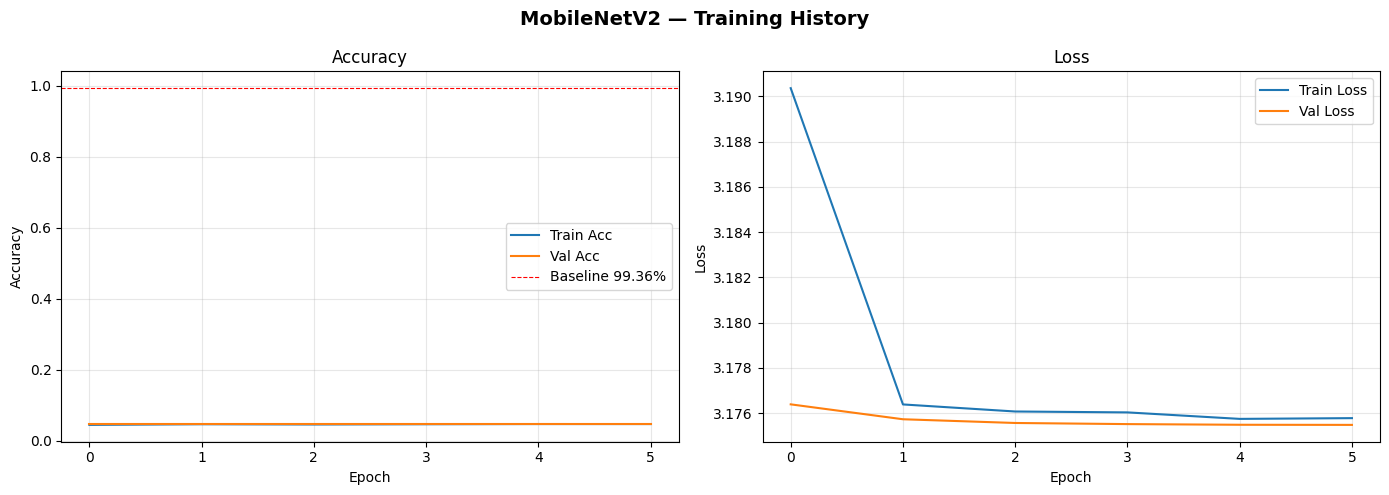

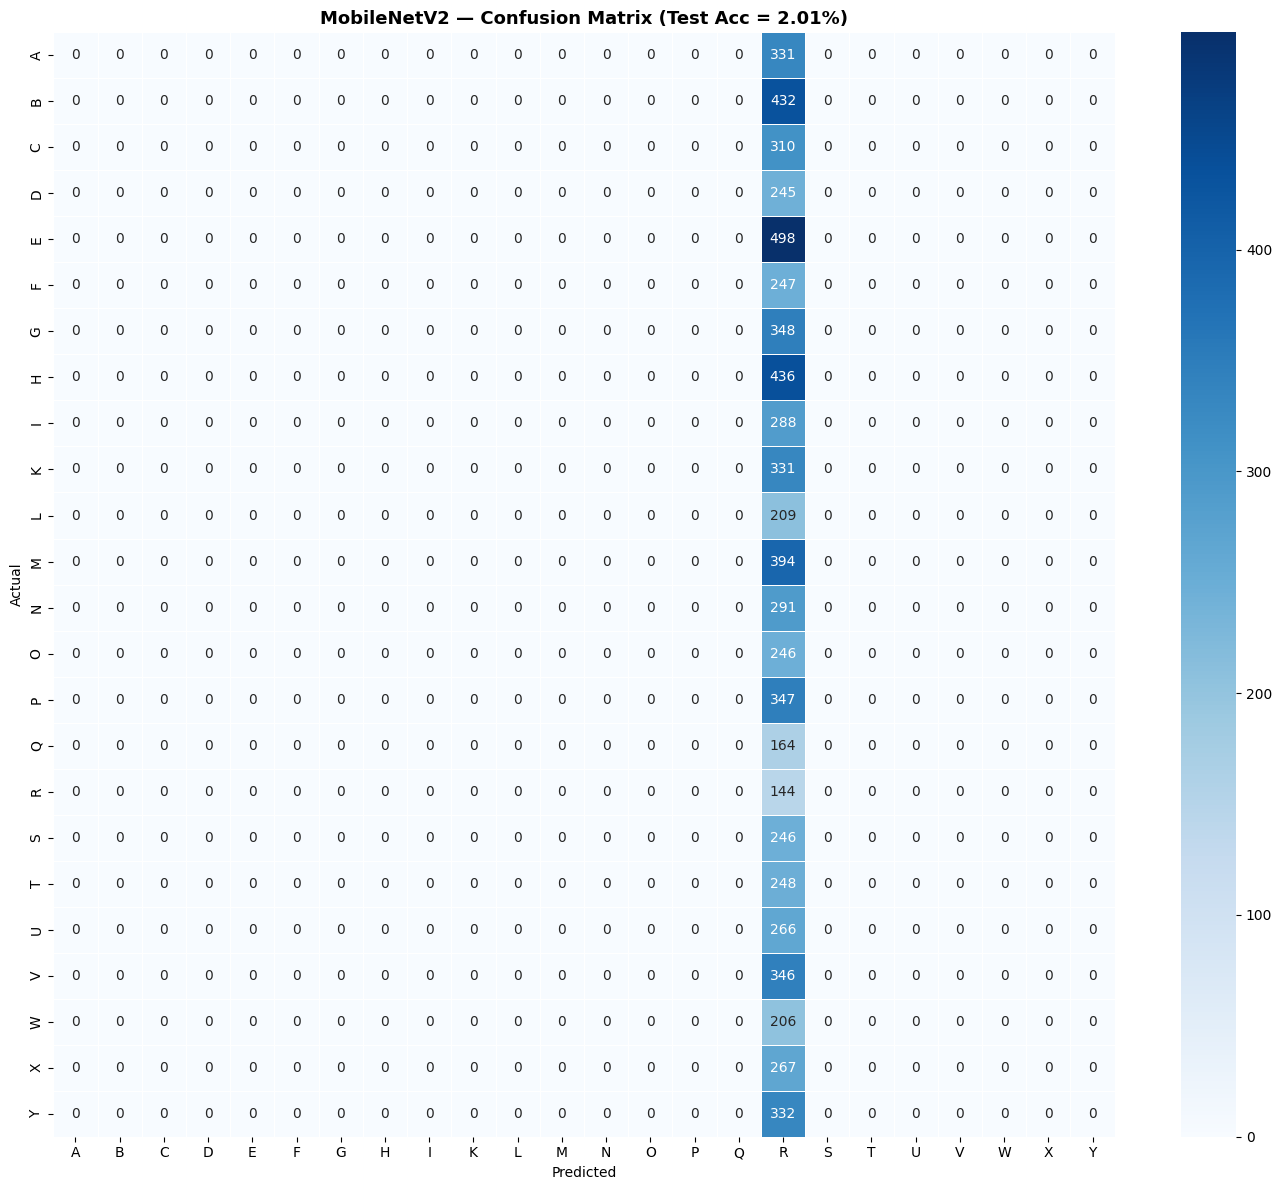


✅  MobileNet plots saved!


In [28]:
# ── Train Best MobileNet Model & Plot ──────────────────
best_mobile_row = df_mobile.iloc[0]
print(f"\n🏆 Training Best MobileNet Config:")
print(f"   lr={best_mobile_row['lr']}, dropout={best_mobile_row['dropout_rate']}, "
      f"unfreeze_last_n={best_mobile_row['unfreeze_last_n']}")

tf.keras.backend.clear_session()
gc.collect()

best_mobile_model = build_mobilenet_basic(
    input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
    num_classes=NUM_CLASSES,
    dropout_rate=best_mobile_row['dropout_rate'],
    dense_units=128,
    lr=best_mobile_row['lr'],
    unfreeze_last_n=int(best_mobile_row['unfreeze_last_n'])
)

cb_final = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

mobile_history = best_mobile_model.fit(
    train_ds_mb,
    validation_data=val_ds_mb,
    epochs=15,
    verbose=1,
    callbacks=cb_final
)

# Evaluate best MobileNet
print(f"\n── MobileNet Evaluation ────────────────────────")
loss_mb, acc_mb = best_mobile_model.evaluate(X_test_mb, y_test_idx_mb, verbose=0)
print(f"Test Loss     : {loss_mb:.4f}")
print(f"Test Accuracy : {acc_mb * 100:.2f}%")
print(f"Delta vs baseline: {(acc_mb * 100) - 99.36:+.2f}%")

y_pred_mb = np.argmax(best_mobile_model.predict(X_test_mb, verbose=0), axis=1)
cm_mb = confusion_matrix(y_test_idx_mb, y_pred_mb)

# Plot MobileNet Training History & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"MobileNetV2 — Training History", fontsize=14, fontweight="bold")

axes[0].plot(mobile_history.history["accuracy"],     label="Train Acc")
axes[0].plot(mobile_history.history["val_accuracy"], label="Val Acc")
axes[0].axhline(0.9936, color="red", linestyle="--", linewidth=0.8, label="Baseline 99.36%")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(mobile_history.history["loss"],     label="Train Loss")
axes[1].plot(mobile_history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/mobilenet_training_history.png", dpi=150)
plt.show()

# MobileNet Confusion Matrix
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_mb, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=ax)
ax.set_title(f"MobileNetV2 — Confusion Matrix (Test Acc = {acc_mb*100:.2f}%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/mobilenet_confusion_matrix.png", dpi=150)
plt.show()

print(f"\n✅  MobileNet plots saved!")